In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
ROOT = Path.cwd()
if ROOT.name == "nullspace_attack":
    ROOT = ROOT.parent
for _p in ["baseline_fgsm_pgd", "smap_msl_data", "telemanom_reproduction", "nullspace_attack", "nullspace_attack_utils", "ldpc", ""]:
    sp = str(ROOT / _p) if _p else str(ROOT)
    if sp not in sys.path:
        sys.path.insert(0, sp)

DATA = ROOT / "smap_msl_data"
RUNS = ROOT / "runs"
PKG  = ROOT / "nullspace_attack"
DLSB = 2.0 ** -7

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
from fgsm_pgd_attacks import load_streams
results = {}
for p in sorted((PKG / "runs_e2").glob("*.json")):
    try:
        r = json.load(open(p))
    except Exception:
        continue
    if isinstance(r, dict) and "min_evasion" in r:
        results[r["chan"]] = r
orc = json.load(open(PKG / "runs_oracle" / "oracle.json"))
e3  = json.load(open(PKG / "runs_e3" / "e3_summary.json"))
half = e3["half_parity"]
_lw  = e3["low_weight"]
dmin = _lw.get("dmin_upper_bound_search", _lw.get("min_pair_weight_found", 272))
def _oracle(key):
    b = sum(1 for r in orc for m in r["labels"] if m[key] is True)
    t = sum(1 for r in orc for m in r["labels"] if m[key] is not None)
    return b, t
e1_brk, e1_tot = _oracle("e1_oracle_missed")
e2_brk, e2_tot = _oracle("e2_oracle_missed")
print(f"loaded {len(results)} E2 channels | oracle breakable E1 {e1_brk}/{e1_tot}, E2 {e2_brk}/{e2_tot}")
print(f"(n-k)/2 = {half:,} | d_min upper bound <= {dmin} | E3 evading channels {len(e3['evasion_vs_samples'])}")

loaded 25 E2 channels | oracle breakable E1 27/27, E2 25/25
(n-k)/2 = 16,200.0 | d_min upper bound <= 272 | E3 evading channels 23


In [2]:
rows = []
for chan, d in results.items():
    tele, _, _, labels, T = load_streams(chan, DATA)
    mask = np.ones(T, bool)
    for a, b in labels:
        mask[max(0, a - 100):min(T, b + 100)] = False
    x = tele[mask]
    sig = float(np.std(x)) / DLSB
    rng = float(np.percentile(x, 95) - np.percentile(x, 5)) / DLSB
    mins = [m["min_evasion_lsb"] for m in d["min_evasion"] if m.get("min_evasion_lsb") is not None]
    me   = min(mins) if mins else None
    fas  = [m["frame_analysis"] for m in d["min_evasion"] if m.get("frame_analysis")]
    cw    = int(np.median([fa["delta_total_weight_med"]    for fa in fas])) if fas else None
    nflag = float(np.mean([fa["frac_frames_naive_flagged"] for fa in fas])) if fas else None
    syn0  = float(np.mean([fa["frac_frames_syndrome0"]     for fa in fas])) if fas else None
    naivew = ([fa["syndrome_naive_weight_med"] for fa in fas if "syndrome_naive_weight_med" in fa] or [None])
    naivew = int(np.median(naivew)) if naivew[0] is not None else None
    attackable = any(m.get("clean_hit_quantized") for m in d["min_evasion"])
    rows.append({"chan": chan, "strat": d.get("stratum", "")[:4], "craft": d["spacecraft"], "n_lbl": len(d["min_evasion"]), "minEvas_LSB": me, "clean_sig_LSB": round(sig, 1), "mE_over_sig": (round(me / sig, 2) if (me and sig > 0) else None), "clip": ("Y" if d.get("clipping_affected") else "."), "cw_wt": cw, "naive_w": naivew, "naive_flag": nflag, "syn0": syn0, "attackable": attackable})
df = pd.DataFrame(rows)
def bucket(r):
    if not r["attackable"]:        return "not-detected(quant)"
    if r["minEvas_LSB"] is None:   return "no-evade"
    s = r["mE_over_sig"]
    if s is None or r["clean_sig_LSB"] < 1: return ">=2sig/flat"
    return "sub-sig" if s < 1 else ("1-2sig" if s < 2 else ">=2sig")
df["class"] = df.apply(bucket, axis=1)
df = df.sort_values("mE_over_sig", na_position="last").reset_index(drop=True)
hdr = (f"{'chan':6}{'strat':5}{'craft':5}{'minEv':>7}{'cln_sig':>8}{'mE/sig':>7}"
       f"{'clip':>5}{'cw_wt':>7}{'naiveSyn':>9}{'flagged':>8}{'syn=0':>7}  class")
print(hdr); print("-" * len(hdr))
for _, r in df.iterrows():
    me  = "--" if pd.isna(r["minEvas_LSB"]) else f"{r['minEvas_LSB']:.0f}"
    s   = "--" if pd.isna(r["mE_over_sig"]) else f"{r['mE_over_sig']:.2f}"
    cw  = "--" if pd.isna(r["cw_wt"]) else f"{r['cw_wt']:.0f}"
    nw  = "--" if pd.isna(r["naive_w"]) else f"{r['naive_w']:.0f}"
    nf  = "--" if pd.isna(r["naive_flag"]) else f"{r['naive_flag']:.0%}"
    s0  = "--" if pd.isna(r["syn0"]) else f"{r['syn0']:.0%}"
    print(f"{r['chan']:6}{str(r['strat']):5}{r['craft']:5}{me:>7}{r['clean_sig_LSB']:>8.0f}{s:>7}"
          f"{r['clip']:>5}{cw:>7}{nw:>9}{nf:>8}{s0:>7}  {r['class']}")
n = len(df)
print(f"\nattackable {df['attackable'].sum()}/{n}  |  sub-sigma {(df['class']=='sub-sig').sum()}  |  "
      f"clipping-affected {(df['clip']=='Y').sum()}")
print(f"null-space syndrome=0 in {df['syn0'].dropna().mean():.0%} of frames  |  "
      f"naive injection flagged in {df['naive_flag'].dropna().mean():.0%} of frames  |  "
      f"median codeword wt {int(df['cw_wt'].dropna().median()):,}")

chan  stratcraft  minEv cln_sig mE/sig clip  cw_wt naiveSyn flagged  syn=0  class
---------------------------------------------------------------------------------
D-1   grad SMAP       1      36   0.01    Y  15444      774    100%   100%  sub-sig
M-3   head MSL        1      67   0.01    .  16264     1118    100%   100%  sub-sig
A-2   head SMAP       7      64   0.11    .  16240     1354    100%   100%  sub-sig
A-4   head SMAP       6      40   0.14    .  16305     2384    100%   100%  sub-sig
A-3   head SMAP       9      55   0.16    .  16454     1604    100%   100%  sub-sig
M-4   head MSL       14      63   0.22    .  16558     2400    100%   100%  sub-sig
M-5   head MSL       17      76   0.22    Y  16384     2292    100%   100%  sub-sig
D-16  head MSL       28      66   0.43    .  16751     2274    100%   100%  sub-sig
T-12  head MSL       27      53   0.51    .  16174     2760    100%   100%  sub-sig
D-11  head SMAP      73     111   0.66    .  16369     1634    100%   100%  sub-

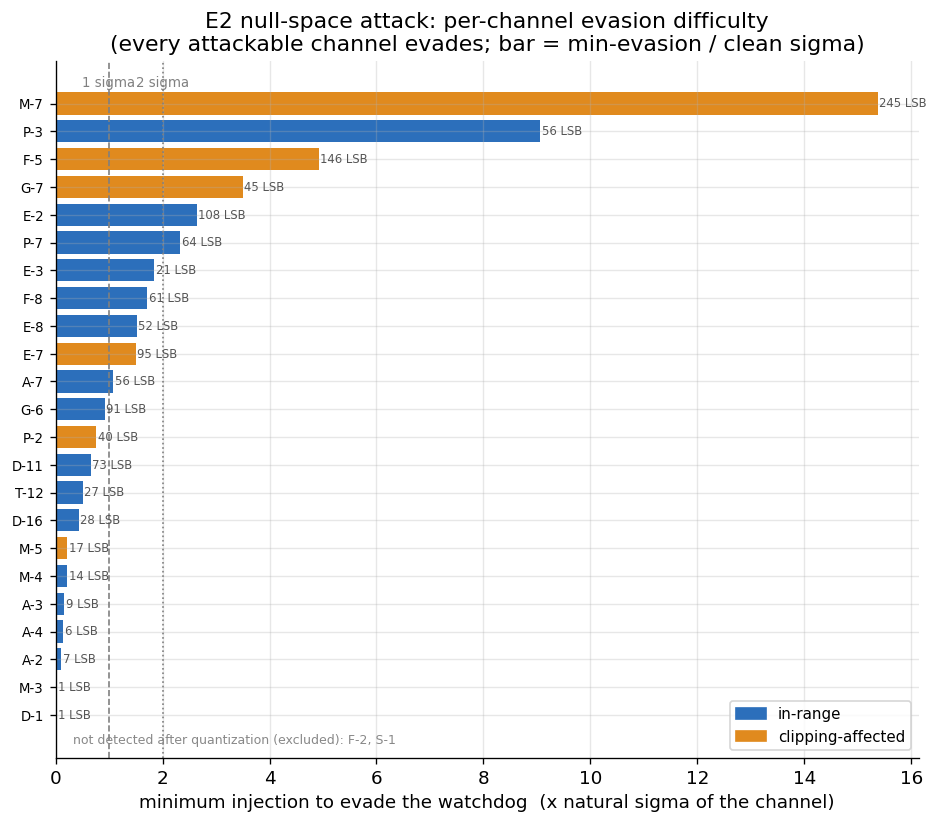

In [3]:
o = df[df["attackable"] & df["minEvas_LSB"].notna() & (df["clean_sig_LSB"] > 0)].copy()
o = o.sort_values("mE_over_sig").reset_index(drop=True)
base = {"in": "#2c6fbb", "clip": "#e08a1e"}
cols = [base["clip"] if c == "Y" else base["in"] for c in o["clip"]]
fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(o))
ax.barh(y, o["mE_over_sig"], color=cols)
ax.set_yticks(y); ax.set_yticklabels(o["chan"], fontsize=8)
for xv, lab, ls in [(1, "1 sigma", "--"), (2, "2 sigma", ":")]:
    ax.axvline(xv, color="gray", ls=ls, lw=1)
    ax.text(xv, len(o) - 0.4, lab, color="gray", ha="center", fontsize=8)
for i, v in enumerate(o["mE_over_sig"]):
    ax.text(v + 0.03, i, f"{o['minEvas_LSB'].iloc[i]:.0f} LSB", va="center", fontsize=7, color="#555")
ax.set_xlabel("minimum injection to evade the watchdog  (x natural sigma of the channel)")
ax.set_title("E2 null-space attack: per-channel evasion difficulty\n"
             "(every attackable channel evades; bar = min-evasion / clean sigma)")
ax.legend(handles=[Patch(color=base["in"], label="in-range"), Patch(color=base["clip"], label="clipping-affected")], loc="lower right", fontsize=9)
notdet = df[~df["attackable"]]["chan"].tolist()
if notdet:
    ax.text(0.02, 0.02, "not detected after quantization (excluded): " + ", ".join(notdet), transform=ax.transAxes, ha="left", fontsize=7.5, color="#888")
plt.tight_layout(); plt.show()

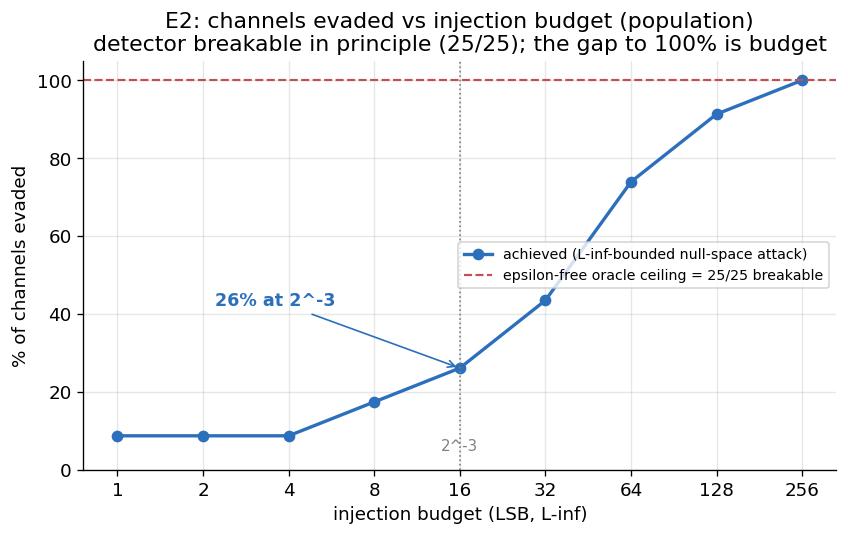

In [4]:
chan_me = sorted(
    min(m["min_evasion_lsb"] for m in d["min_evasion"]
        if m.get("clean_hit_quantized") and m.get("min_evasion_lsb") is not None)
    for d in results.values()
    if any(m.get("clean_hit_quantized") and m.get("min_evasion_lsb") is not None for m in d["min_evasion"]))
chan_me = np.array(chan_me)
grid = [1, 2, 4, 8, 16, 32, 64, 128, 256]
pct  = [100 * np.mean(chan_me <= g) for g in grid]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(grid, pct, "o-", color="#2c6fbb", lw=2, label="achieved (L-inf-bounded null-space attack)")
ax.axhline(100, color="#c44e52", ls="--", lw=1.3,
           label=f"epsilon-free oracle ceiling = {e2_brk}/{e2_tot} breakable")
ax.axvline(16, color="gray", ls=":", lw=1)
ax.text(16, 5, "2^-3", color="gray", ha="center", fontsize=9)
f16 = 100 * np.mean(chan_me <= 16)
ax.annotate(f"{f16:.0f}% at 2^-3", xy=(16, f16), xytext=(2.2, f16 + 16),
            fontsize=10.5, color="#2c6fbb", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#2c6fbb"))
ax.set_xscale("log", base=2); ax.set_xticks(grid); ax.set_xticklabels([str(g) for g in grid])
ax.set_xlabel("injection budget (LSB, L-inf)"); ax.set_ylabel("% of channels evaded")
ax.set_ylim(0, 105)
ax.set_title("E2: channels evaded vs injection budget (population)\n"
             f"detector breakable in principle ({e2_brk}/{e2_tot}); the gap to 100% is budget")
ax.legend(fontsize=8.5, loc="center right")
plt.tight_layout(); plt.show()

case study: A-4  budget 6 LSB  (channel min-evasion 5.7 LSB)


/home/jovyan/work/SecureSpace/telemanom_reproduction/pipeline.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(model_path, map_location="cpu")


evaded(lattice)=True  L-inf=6.0 LSB = 0.15 sigma  | delta_info weight 1809 bits
LDPC syndrome: null-space = 0 (passes) ; naive injection = 2322 (flagged) ; codeword wt 16,541


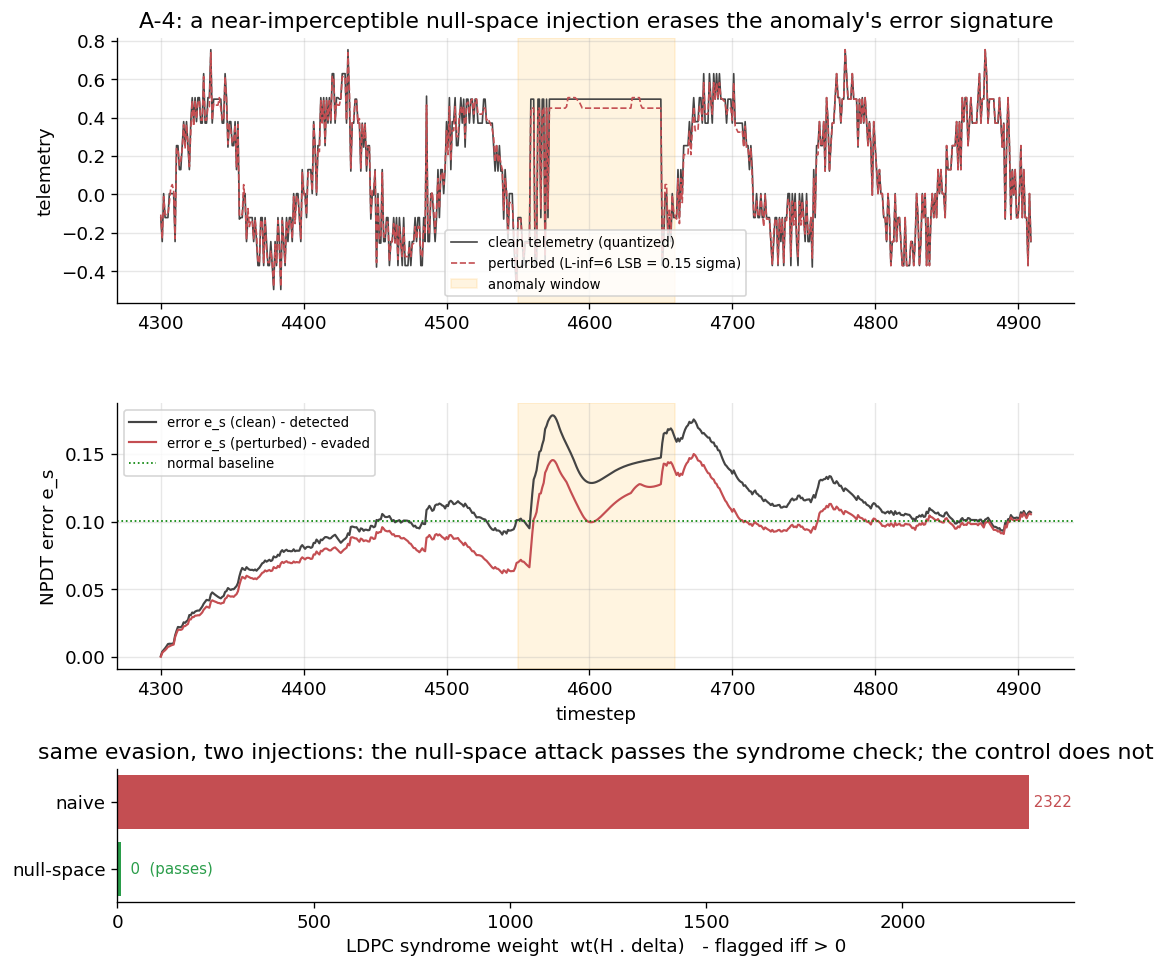

In [5]:
import torch
from pipeline import load_trained_model
from fgsm_pgd_attacks import prepare_model, detect, load_streams, DEVICE, VendoredConfig
from ceil_attack import CeilingConfig
from nullspace_attack.nullspace_attack import c2_ceiling_attack
from frame_ops import get_long_code, frame_analysis_over_stream
from smap_msl_dataset_api import Quantizer

cand = [c for c in results if any(m.get("clean_hit_quantized") and m.get("min_evasion_lsb") is not None for m in results[c]["min_evasion"]) and not results[c].get("clipping_affected")]
CHAN = "A-4" if "A-4" in cand else cand[0]
me_chan = min(m["min_evasion_lsb"] for m in results[CHAN]["min_evasion"] if m.get("min_evasion_lsb") is not None)
BUDGET_LSB = float(np.ceil(me_chan))
print(f"case study: {CHAN}  budget {BUDGET_LSB:.0f} LSB  (channel min-evasion {me_chan:.1f} LSB)")
cfg, ccfg, q = VendoredConfig(), CeilingConfig(), Quantizer()
tele, cmds, train_features, labels, T = load_streams(CHAN, DATA)
model = prepare_model(load_trained_model(RUNS / CHAN / "model.pt", n_features=train_features.shape[1], device=DEVICE))
label = labels[0]; a, b = int(label[0]), int(label[1])
res = c2_ceiling_attack(CHAN, model, train_features, tele, cmds, labels, label, cfg, ccfg, BUDGET_LSB * DLSB, q, return_arrays=True)
tele_q   = res["_tele_q"]
tele_recv = tele_q + res["_delta_snap"]
linf = res["realized_linf_lsb"]
mask = (np.arange(T) < a - 100) | (np.arange(T) > b + 100)
sig  = float(np.std(tele[mask])) / DLSB
import torch
from ceil_attack import _ewma_span, _es_over
span = _ewma_span(cfg); alpha = 2.0/(span+1); K = 8*span
cmds_t = torch.tensor(cmds.astype(np.float32), device=DEVICE)
tau_q  = torch.tensor(tele_q.astype(np.float32), device=DEVICE)
tau_rv = torch.tensor(tele_recv.astype(np.float32), device=DEVICE)
lo, hi = max(0, a - 250), min(T, b + 250)
R = np.arange(max(0, lo - cfg.l_s), min(T - cfg.l_s - cfg.n_predictions, hi - cfg.l_s))
R_t = torch.tensor(R, device=DEVICE, dtype=torch.long)
with torch.no_grad():
    E_cln = _es_over(model, tau_q,  torch.zeros(T, device=DEVICE), cmds_t, R_t, cfg.l_s, alpha, K, 512, False).cpu().numpy()
    E_prt = _es_over(model, tau_rv, torch.zeros(T, device=DEVICE), cmds_t, R_t, cfg.l_s, alpha, K, 512, False).cpu().numpy()
xes = R + cfg.l_s
fa = frame_analysis_over_stream(res["_delta_info_bits"], code=get_long_code(), window=100, slot=0)
naive_w, cw = fa["syndrome_naive_weight_med"], fa["delta_total_weight_med"]
print(f"evaded(lattice)={res['ceiling_missed']}  L-inf={linf:.1f} LSB = {linf/sig:.2f} sigma  "
      f"| delta_info weight {res['delta_info_weight_stream']} bits")
print(f"LDPC syndrome: null-space = 0 (passes) ; naive injection = {naive_w} (flagged) ; codeword wt {cw:,}")
lo, hi = max(0, a - 250), min(T, b + 250)
m = (xes >= lo) & (xes < hi)
fig, ax = plt.subplots(3, 1, figsize=(9.2, 8.2), gridspec_kw={"height_ratios": [1.1, 1.1, 0.55]})
ax[0].plot(range(lo, hi), tele_q[lo:hi], color="#444", lw=1.0, label="clean telemetry (quantized)")
ax[0].plot(range(lo, hi), tele_recv[lo:hi], color="#c44e52", lw=1.0, ls="--", label=f"perturbed (L-inf={linf:.0f} LSB = {linf/sig:.2f} sigma)")
ax[0].axvspan(a, b, color="orange", alpha=0.12, label="anomaly window")
ax[0].set_ylabel("telemetry"); ax[0].legend(fontsize=8, loc="best")
ax[0].set_title(f"{CHAN}: a near-imperceptible null-space injection erases the anomaly's error signature")
ax[1].plot(xes[m], E_cln[m], color="#444", lw=1.3, label="error e_s (clean) - detected")
ax[1].plot(xes[m], E_prt[m], color="#c44e52", lw=1.3, label="error e_s (perturbed) - evaded")
ax[1].axhline(res["baseline_b"], color="green", ls=":", lw=1, label="normal baseline")
ax[1].axvspan(a, b, color="orange", alpha=0.12)
ax[1].set_ylabel("NPDT error e_s"); ax[1].set_xlabel("timestep"); ax[1].legend(fontsize=8, loc="best")
ax[2].barh([1], [naive_w], color="#c44e52", label="naive injection (flagged)")
ax[2].barh([0], [max(naive_w * 0.004, 1)], color="#2a9d4a")
ax[2].text(naive_w, 1, f" {naive_w}", va="center", fontsize=9, color="#c44e52")
ax[2].text(max(naive_w * 0.004, 1), 0, "  0  (passes)", va="center", fontsize=9, color="#2a9d4a")
ax[2].set_yticks([0, 1]); ax[2].set_yticklabels(["null-space", "naive"])
ax[2].set_xlabel("LDPC syndrome weight  wt(H . delta)   - flagged iff > 0")
ax[2].set_title("same evasion, two injections: the null-space attack passes the syndrome check; the control does not")
ax[2].grid(False)
plt.tight_layout(); plt.show()

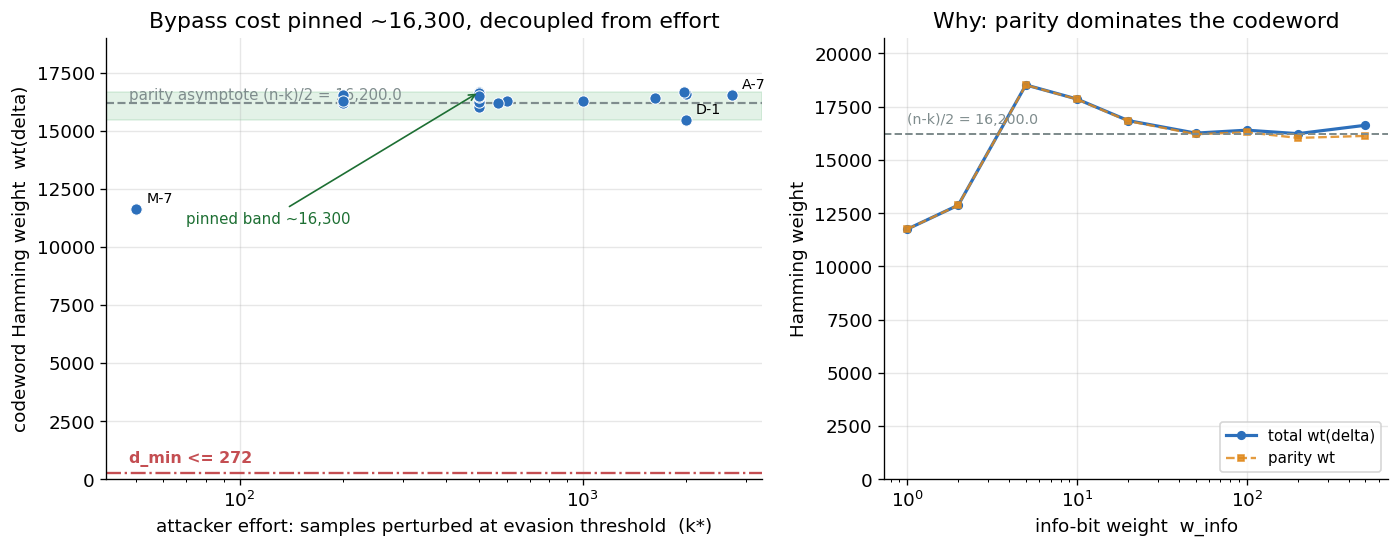

In [6]:
ev= e3["evasion_vs_samples"]
ks = np.array([e["k_star_samples"] for e in ev], float)
ws = np.array([e["codeword_wt_at_kstar"] for e in ev], float)
names = [e["chan"] for e in ev]
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.8, 4.7), gridspec_kw={"width_ratios": [1.3, 1]})
band_lo = float(min(w for w in ws if w > 14000)); band_hi = float(ws.max())
axL.axhspan(band_lo, band_hi, color="#2a9d4a", alpha=0.13)
axL.axhline(half, color="#7f8c8d", ls="--", lw=1.3)
axL.text(ks.min() * 0.95, half + 130, f"parity asymptote (n-k)/2 = {half:,}", fontsize=9, color="#7f8c8d")
axL.axhline(dmin, color="#c44e52", ls="-.", lw=1.4)
axL.text(ks.min() * 0.95, dmin + 430, f"d_min <= {dmin}", fontsize=9.5, color="#c44e52", fontweight="bold")
axL.scatter(ks, ws, s=46, color="#2c6fbb", zorder=3, edgecolor="white", linewidth=0.6)
for x, y, nm in zip(ks, ws, names):
    if y < 14000 or nm in ("A-7", "D-1"):
        axL.annotate(nm, (x, y), textcoords="offset points", xytext=(6, 4), fontsize=8.5)
axL.annotate("pinned band ~16,300", xy=(ks[int(np.argmax(ws))], band_hi), xytext=(ks.min() * 1.4, band_hi * 0.66), fontsize=9, color="#1d6f33", arrowprops=dict(arrowstyle="->", color="#1d6f33"))
axL.set_xscale("log"); axL.set_ylim(0, max(half, band_hi) * 1.14)
axL.set_xlabel("attacker effort: samples perturbed at evasion threshold  (k*)")
axL.set_ylabel("codeword Hamming weight  wt(delta)")
axL.set_title("Bypass cost pinned ~16,300, decoupled from effort") 
pc  = e3["parity_curve"]
wi  = [c["w_info"] for c in pc]
tot = [c["wt_total_med"] for c in pc]
par = [c.get("wt_parity_med", c["wt_total_med"]) for c in pc]
axR.plot(wi, tot, "o-", color="#2c6fbb", lw=1.9, ms=4.5, label="total wt(delta)")
axR.plot(wi, par, "s--", color="#e08a1e", lw=1.4, ms=3.5, alpha=0.85, label="parity wt")
axR.axhline(half, color="#7f8c8d", ls="--", lw=1.2)
axR.text(wi[0], half * 1.03, f"(n-k)/2 = {half:,}", fontsize=8.5, color="#7f8c8d")
axR.set_xscale("log"); axR.set_ylim(0, max(tot) * 1.12)
axR.set_xlabel("info-bit weight  w_info"); axR.set_ylabel("Hamming weight")
axR.set_title("Why: parity dominates the codeword"); axR.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()